# 01 · Linear Regression from First Principles

> **DS100 — Data Science Masterclass**  
> *Wear the hat of a technical expert **and** an intuitive teacher.*

---

## What you will build

| # | Method | Key idea |
|---|--------|----------|
| 1 | **Normal Equation** (analytical) | Calculus + linear algebra → closed-form formula |
| 2 | **Batch Gradient Descent** (iterative) | Follow the slope of the loss landscape, step by step |

Both implementations use **only NumPy** — no scikit-learn for the algorithm itself.  
At the end we validate against `sklearn.LinearRegression` to confirm correctness.

---

## Road map

```
Part 0 — Intuition & Setup
Part 1 — Mathematical Foundations  (vectors, matrices, dot products)
Part 2 — Problem Formulation        (design matrix, loss function)
Part 3 — Normal Equation            (derivation → code)
Part 4 — Gradient Descent           (derivation → code → visualisation)
Part 5 — Comparison & Validation
```

---
# Part 0 — Intuition

**What problem are we solving?**

You have a spreadsheet of houses:
- columns: size (sqft), number of bedrooms, age …
- one special column: **price** (what we want to predict)

Linear regression answers: *"Can I draw a flat surface through this data so that I can predict price from features?"*

The word **linear** means the prediction is a **weighted sum** of the features:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

Our job: find the coefficients $\beta_0, \beta_1, \ldots, \beta_p$ that make $\hat{y}$ as close to the real $y$ as possible.

| Symbol | Role |
|--------|------|
| $\beta_0$ | **Intercept** — the baseline prediction when all features are zero |
| $\beta_1, \ldots, \beta_p$ | **Slopes** — how much $\hat{y}$ changes per unit increase in each feature |

---
# Part 1 — Mathematical Foundations

## 1.1 Vectors

A **vector** $\mathbf{v} \in \mathbb{R}^n$ is an ordered list of $n$ real numbers:

$$
\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}
$$

**Geometric intuition**: an arrow in $n$-dimensional space pointing from the origin to the point $(v_1, v_2, \ldots, v_n)$.

---

## 1.2 The Dot Product — the engine of linear algebra

Given two vectors $\mathbf{a}, \mathbf{b} \in \mathbb{R}^n$:

$$
\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta
$$

where $\theta$ is the angle between the two vectors.

**Why does it matter for regression?**  
The prediction $\hat{y} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$ is *exactly* a dot product:

$$
\hat{y} = \mathbf{x} \cdot \boldsymbol{\beta} \quad \text{where} \quad
\mathbf{x} = \begin{bmatrix}1 \\ x_1 \\ \vdots \\ x_p\end{bmatrix}, \quad
\boldsymbol{\beta} = \begin{bmatrix}\beta_0 \\ \beta_1 \\ \vdots \\ \beta_p\end{bmatrix}
$$

The leading 1 in $\mathbf{x}$ absorbs the intercept $\beta_0$, so the dot product computes  
$1 \cdot \beta_0 + x_1 \cdot \beta_1 + \cdots + x_p \cdot \beta_p$ — exactly the regression formula.

---

## 1.3 Matrix–vector product — predicting all samples at once

If we stack $n$ samples as rows in a matrix $\mathbf{X} \in \mathbb{R}^{n \times (p+1)}$, then:

$$
\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}
$$

gives us **all** $n$ predictions in one shot.  
Row $i$ of $\mathbf{X}$ dotted with $\boldsymbol{\beta}$ = prediction for sample $i$.

---

## 1.4 The $\ell_2$ norm — measuring distance

$$
\|\mathbf{v}\|_2 = \sqrt{\sum_{i=1}^n v_i^2} = \sqrt{\mathbf{v}^\top \mathbf{v}}
$$

We will minimise $\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|_2^2$ — the **squared** norm of the residual vector.

In [1]:
# --- Foundations live demo ---
import numpy as np

a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

print("Dot product (np.dot)  :", np.dot(a, b))
print("Dot product (manual)  :", sum(ai*bi for ai, bi in zip(a, b)))
print("L2 norm of a          :", np.linalg.norm(a))
print("Manual L2 norm        :", np.sqrt(np.sum(a**2)))

Dot product (np.dot)  : 32.0
Dot product (manual)  : 32.0
L2 norm of a          : 3.7416573867739413
Manual L2 norm        : 3.7416573867739413


---
# Part 2 — Problem Formulation

## 2.1 Dataset notation

| Symbol | Meaning | Shape |
|--------|---------|-------|
| $n$ | number of training samples | scalar |
| $p$ | number of raw features | scalar |
| $\mathbf{X}$ | **design matrix** (bias column prepended) | $n \times (p+1)$ |
| $\mathbf{y}$ | target vector | $n \times 1$ |
| $\boldsymbol{\beta}$ | coefficient vector — $[\beta_0, \beta_1, \ldots, \beta_p]^\top$ (what we learn) | $(p+1) \times 1$ |

$$
\mathbf{X} = \begin{bmatrix}
1 & x_{1,1} & x_{1,2} & \cdots & x_{1,p} \\
1 & x_{2,1} & x_{2,2} & \cdots & x_{2,p} \\
\vdots & & & & \vdots \\
1 & x_{n,1} & x_{n,2} & \cdots & x_{n,p}
\end{bmatrix}
$$

The first column of all 1s pairs with $\beta_0$ to produce the intercept term in every prediction.

---

## 2.2 The Loss Function — Mean Squared Error (MSE)

We want predictions close to targets. Define the **residual vector**:

$$
\mathbf{r} = \mathbf{y} - \mathbf{X}\boldsymbol{\beta}
$$

The **MSE loss** is:

$$
\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
= \frac{1}{n} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2
= \frac{1}{n} (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})
$$

**Why squared?**  
- Penalises large errors more than small ones  
- Differentiable everywhere (unlike absolute value at 0)  
- Leads to a beautiful closed-form solution

**Why divide by $n$?**  
So the loss doesn't grow just because we collect more data.

X shape : (100, 2)   (n=100 samples, p+1=2 columns)
y shape : (100,)

First 4 rows of X:
[[1.         7.73956049]
 [1.         4.3887844 ]
 [1.         8.5859792 ]
 [1.         6.97368029]]


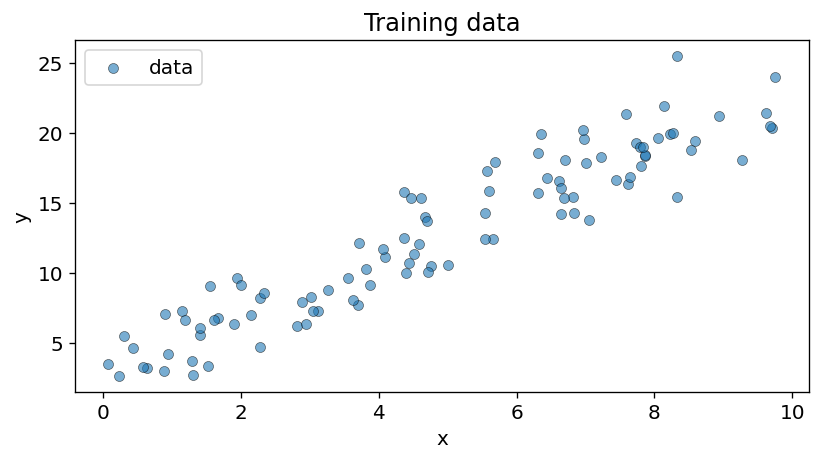

In [2]:
# --- Dataset generation (used throughout the notebook) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({'font.size': 12, 'figure.dpi': 120})

rng = np.random.default_rng(42)

# True data-generating process:  y = beta0 + beta1*x + noise
TRUE_BETA0 = 3.0   # true intercept
TRUE_BETA1 = 2.0   # true slope

n = 100
x_raw = rng.uniform(0, 10, size=n)
noise  = rng.normal(0, 2, size=n)
y      = TRUE_BETA0 + TRUE_BETA1 * x_raw + noise

# Build design matrix X: shape (n, 2)  — column of 1s + x_raw
X = np.column_stack([np.ones(n), x_raw])   # shape (100, 2)

print(f"X shape : {X.shape}   (n=100 samples, p+1=2 columns)")
print(f"y shape : {y.shape}")
print("\nFirst 4 rows of X:")
print(X[:4])

# Quick scatter
plt.figure(figsize=(7, 4))
plt.scatter(x_raw, y, alpha=0.6, edgecolors='k', linewidths=0.4, label='data')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Training data')
plt.legend(); plt.tight_layout(); plt.show()

---
# Part 3 — Normal Equation (Analytical Solution)

## 3.1 Derivation

We want to minimise:

$$
\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2
$$

**Step 1 — Expand the squared norm**

$$
\mathcal{L} = \frac{1}{n}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})
= \frac{1}{n}\left(
    \mathbf{y}^\top\mathbf{y}
    - 2\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y}
    + \boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta}
\right)
$$

**Step 2 — Differentiate with respect to $\boldsymbol{\beta}$**

Using matrix calculus identities:
- $\dfrac{\partial}{\partial \boldsymbol{\beta}}(\mathbf{a}^\top \boldsymbol{\beta}) = \mathbf{a}$
- $\dfrac{\partial}{\partial \boldsymbol{\beta}}(\boldsymbol{\beta}^\top \mathbf{A} \boldsymbol{\beta}) = 2\mathbf{A}\boldsymbol{\beta}$ (when $\mathbf{A}$ is symmetric)

$$
\frac{\partial \mathcal{L}}{\partial \boldsymbol{\beta}}
= \frac{1}{n}\left(-2\mathbf{X}^\top\mathbf{y} + 2\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta}\right)
$$

**Step 3 — Set gradient to zero**

$$
-2\mathbf{X}^\top\mathbf{y} + 2\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} = \mathbf{0}
$$

$$
\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y}
$$

$$
\boxed{\boldsymbol{\beta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}
$$

This is the **Normal Equation**. One matrix inversion — done.

---

## 3.2 Geometric intuition

The column space of $\mathbf{X}$ is a $(p+1)$-dimensional subspace of $\mathbb{R}^n$.  
$\mathbf{y}$ probably does **not** lie in that subspace (noise).  
The normal equation finds the **orthogonal projection** of $\mathbf{y}$ onto the column space — the closest point reachable by $\mathbf{X}\boldsymbol{\beta}$.

> "*The best-fit line is the one where the residuals are perpendicular to every direction in which we can move the line.*"

---

## 3.3 Complexity note

- $\mathbf{X}^\top\mathbf{X}$ : $O(np^2)$
- Matrix inversion: $O(p^3)$
- Total: fine for $p < 10^4$, painful beyond that → use gradient descent

In [12]:
# ============================================================
# IMPLEMENTATION 1 — Normal Equation
# beta* = (X^T X)^{-1} X^T y
# ============================================================

class LinearRegressionNormal:
    """Ordinary Least Squares via the Normal Equation."""

    def __init__(self):
        self.beta_ = None       # learned coefficients [beta0, beta1, ...]

    def fit(self, X, y):
        """
        Parameters
        ----------
        X : ndarray, shape (n, p+1)  — design matrix WITH bias column
        y : ndarray, shape (n,)
        """
        XtX = X.T @ X                              # (p+1) x (p+1)
        Xty = X.T @ y                              # (p+1,)
        self.beta_ = np.linalg.solve(XtX, Xty)    # numerically stable vs. explicit inverse
        return self

    def predict(self, X):
        return X @ self.beta_

    def mse(self, X, y):
        residuals = y - self.predict(X)
        return np.mean(residuals ** 2)


# --- Fit on our dataset ---
model_normal = LinearRegressionNormal().fit(X, y)

b0_ne, b1_ne = model_normal.beta_
print("=== Normal Equation ===")
print(f"  beta0 (intercept) : {b0_ne:.4f}   (true = {TRUE_BETA0})")
print(f"  beta1 (slope)     : {b1_ne:.4f}   (true = {TRUE_BETA1})")
print(f"  Train MSE         : {model_normal.mse(X, y):.4f}")

=== Normal Equation ===
  beta0 (intercept) : 2.8974   (true = 3.0)
  beta1 (slope)     : 2.0153   (true = 2.0)
  Train MSE         : 3.8355


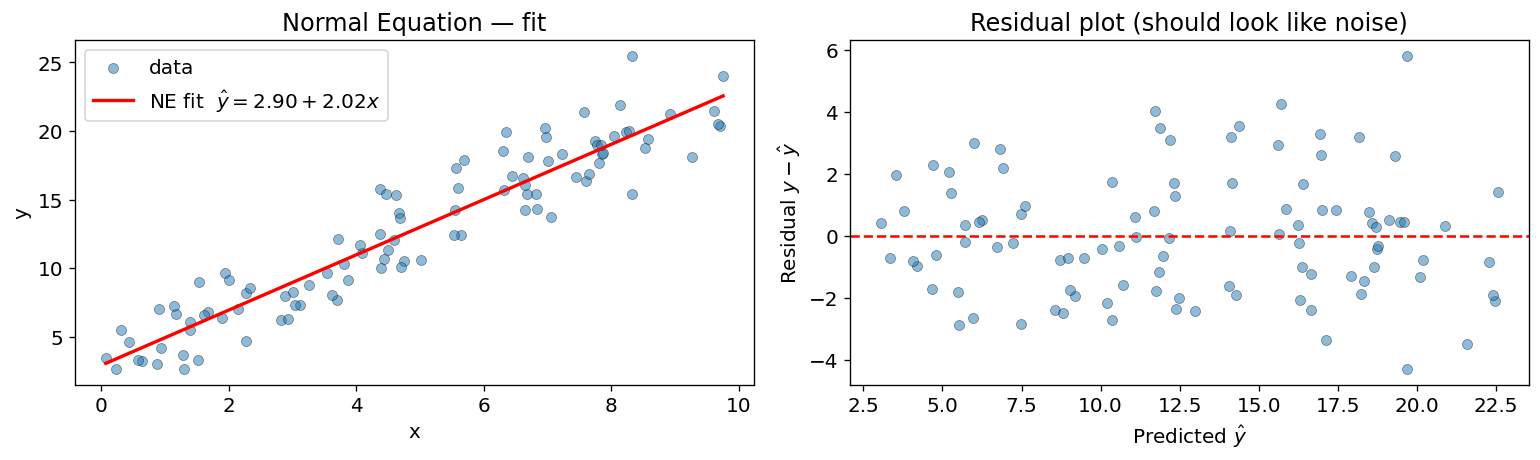

In [4]:
# --- Visualise the fit ---
x_line = np.linspace(x_raw.min(), x_raw.max(), 200)
X_line = np.column_stack([np.ones(200), x_line])
y_hat_ne = model_normal.predict(X_line)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: fit
ax = axes[0]
ax.scatter(x_raw, y, alpha=0.5, edgecolors='k', linewidths=0.4, label='data')
ax.plot(x_line, y_hat_ne, 'r-', lw=2,
        label=f'NE fit  $\\hat{{y}}={b0_ne:.2f}+{b1_ne:.2f}x$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Normal Equation — fit'); ax.legend()

# Right: residuals
ax = axes[1]
residuals = y - model_normal.predict(X)
ax.scatter(model_normal.predict(X), residuals, alpha=0.5, edgecolors='k', linewidths=0.4)
ax.axhline(0, color='r', lw=1.5, ls='--')
ax.set_xlabel('Predicted $\\hat{y}$'); ax.set_ylabel('Residual $y - \\hat{y}$')
ax.set_title('Residual plot (should look like noise)')

plt.tight_layout(); plt.show()

---
# Part 4 — Gradient Descent (Iterative Solution)

## 4.1 Motivation

The normal equation requires inverting $\mathbf{X}^\top\mathbf{X}$.  
- For $p = 10^6$ features, that's a $10^6 \times 10^6$ matrix — infeasible.  
- Gradient descent sidesteps the inversion entirely.

**Core idea**: stand on the loss surface, look downhill, take a small step. Repeat.

---

## 4.2 The Gradient of MSE

Recall:
$$
\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2
$$

We already derived:
$$
\nabla_{\boldsymbol{\beta}}\mathcal{L}
= \frac{-2}{n}\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})
= \frac{2}{n}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\beta} - \mathbf{y})
$$

Expanding term by term for coefficient $j$:

$$
\frac{\partial \mathcal{L}}{\partial \beta_j} = \frac{-2}{n} \sum_{i=1}^n x_{ij}\,(y_i - \hat{y}_i)
$$

**Intuition**: if the predictions are too low for large $x_j$ values, the gradient is negative — push $\beta_j$ up.

---

## 4.3 The Update Rule

$$
\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \alpha \, \nabla_{\boldsymbol{\beta}}\mathcal{L}\big|_{\boldsymbol{\beta}^{(t)}}
$$

where $\alpha > 0$ is the **learning rate** — how big a step to take.

| $\alpha$ too large | $\alpha$ too small |
|-------------------|--------------------||
| Overshoots, diverges | Converges, but very slowly |

---

## 4.4 Convergence guarantee

MSE is a **convex, quadratic** function — it has exactly one minimum.  
Gradient descent is guaranteed to converge to it (given a small enough $\alpha$).

The eigenvalues of $\mathbf{X}^\top\mathbf{X}$ control convergence speed.  
A safe upper bound: $\alpha < \dfrac{1}{\lambda_{\max}(\mathbf{X}^\top\mathbf{X})/n}$.

In [16]:
# ============================================================
# IMPLEMENTATION 2 — Batch Gradient Descent
# beta_{t+1} = beta_t - alpha * (2/n) * X^T (X beta_t - y)
# ============================================================

class LinearRegressionGD:
    """Ordinary Least Squares via Batch Gradient Descent."""

    def __init__(self, lr=0.01, n_iters=1000, tol=1e-8):
        self.lr       = lr
        self.n_iters  = n_iters
        self.tol      = tol
        self.beta_    = None
        self.history_ = []     # MSE per iteration

    def _gradient(self, X, y):
        n = len(y)
        residuals = X @ self.beta_ - y          # shape (n,)
        return (2 / n) * (X.T @ residuals)      # shape (p+1,)

    def _mse(self, X, y):
        return np.mean((y - X @ self.beta_) ** 2)

    def fit(self, X, y):
        """
        Parameters
        ----------
        X : ndarray, shape (n, p+1)  — design matrix WITH bias column
        y : ndarray, shape (n,)
        """
        rng = np.random.default_rng(0)
        self.beta_ = rng.normal(0, 0.01, size=X.shape[1])  # small random init
        self.history_ = []

        for t in range(self.n_iters):
            grad = self._gradient(X, y)
            self.beta_ -= self.lr * grad

            mse = self._mse(X, y)
            self.history_.append(mse)

            # Early stopping when improvement is negligible
            if t > 0 and abs(self.history_[-2] - mse) < self.tol:
                print(f"  Converged at iteration {t}")
                break

        return self

    def predict(self, X):
        return X @ self.beta_

    def mse(self, X, y):
        return np.mean((y - self.predict(X)) ** 2)


# --- Fit ---
model_gd = LinearRegressionGD(lr=0.01, n_iters=5000).fit(X, y)

b0_gd, b1_gd = model_gd.beta_
print("=== Gradient Descent ===")
print(f"  beta0 (intercept) : {b0_gd:.4f}   (true = {TRUE_BETA0})")
print(f"  beta1 (slope)     : {b1_gd:.4f}   (true = {TRUE_BETA1})")
print(f"  Train MSE         : {model_gd.mse(X, y):.4f}")

  Converged at iteration 1518
=== Gradient Descent ===
  beta0 (intercept) : 2.8953   (true = 3.0)
  beta1 (slope)     : 2.0157   (true = 2.0)
  Train MSE         : 3.8355


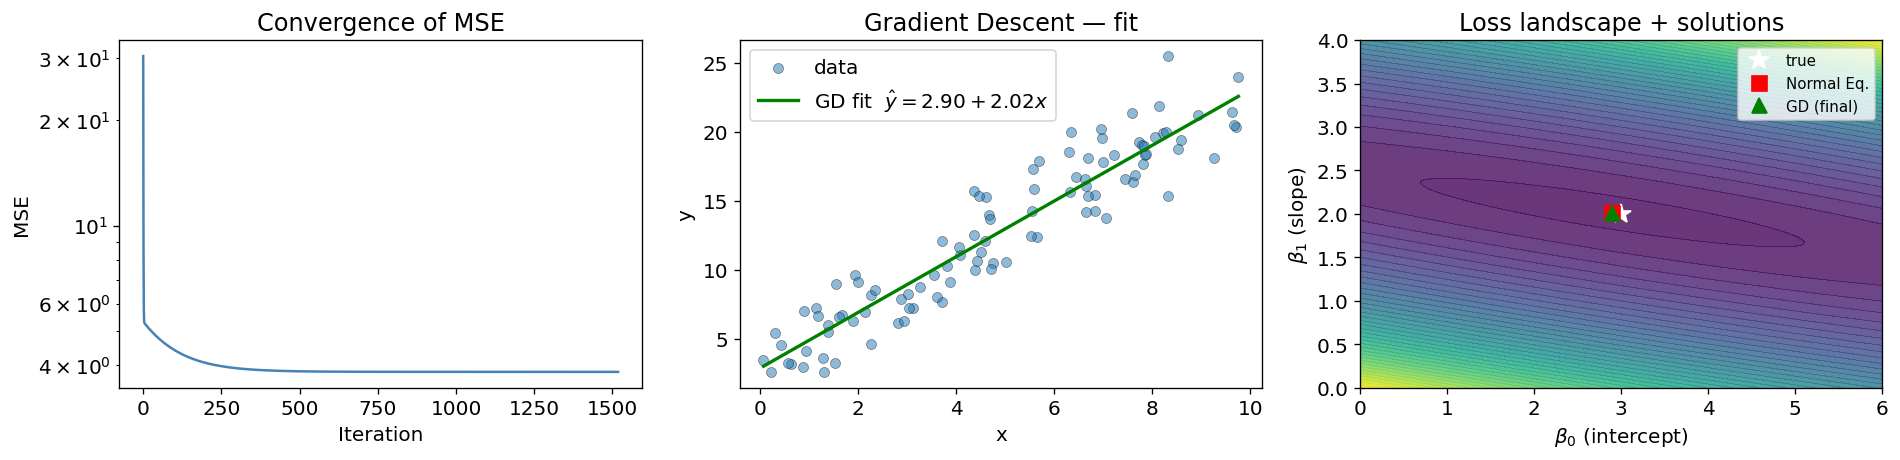

: 

In [ ]:
# --- Visualise convergence ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Loss curve
ax = axes[0]
ax.plot(model_gd.history_, color='steelblue', lw=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('MSE')
ax.set_title('Convergence of MSE')
ax.set_yscale('log')

# 2) GD fit vs data
ax = axes[1]
y_hat_gd = model_gd.predict(X_line)
ax.scatter(x_raw, y, alpha=0.5, edgecolors='k', linewidths=0.4, label='data')
ax.plot(x_line, y_hat_gd, 'g-', lw=2,
        label=f'GD fit  $\\hat{{y}}={b0_gd:.2f}+{b1_gd:.2f}x$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gradient Descent — fit'); ax.legend()

# 3) Coefficient trajectory (beta0 vs beta1) on loss contours
ax = axes[2]
B0 = np.linspace(0, 6, 120)
B1 = np.linspace(0, 4, 120)
B0g, B1g = np.meshgrid(B0, B1)
Z = np.array([
    np.mean((y - (b0 + b1 * x_raw))**2)
    for b0, b1 in zip(B0g.ravel(), B1g.ravel())
]).reshape(B0g.shape)
ax.contourf(B0g, B1g, Z, levels=40, cmap='viridis', alpha=0.8)
ax.plot(TRUE_BETA0, TRUE_BETA1, 'w*', ms=12, label='true')
ax.plot(b0_ne, b1_ne, 'rs', ms=9, label='Normal Eq.')
ax.plot(b0_gd, b1_gd, 'g^', ms=9, label='GD (final)')
ax.set_xlabel('$\\beta_0$ (intercept)'); ax.set_ylabel('$\\beta_1$ (slope)')
ax.set_title('Loss landscape + solutions'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

---
# Part 4B — Effect of Learning Rate

Three regimes worth seeing:

| Learning rate | Behaviour |
|---|---|
| Too small ($\alpha = 10^{-4}$) | Converges, but takes thousands of steps |
| Just right ($\alpha = 10^{-2}$) | Fast, smooth convergence |
| Too large ($\alpha = 0.5$) | Diverges (loss explodes) |

  Converged at iteration 1518


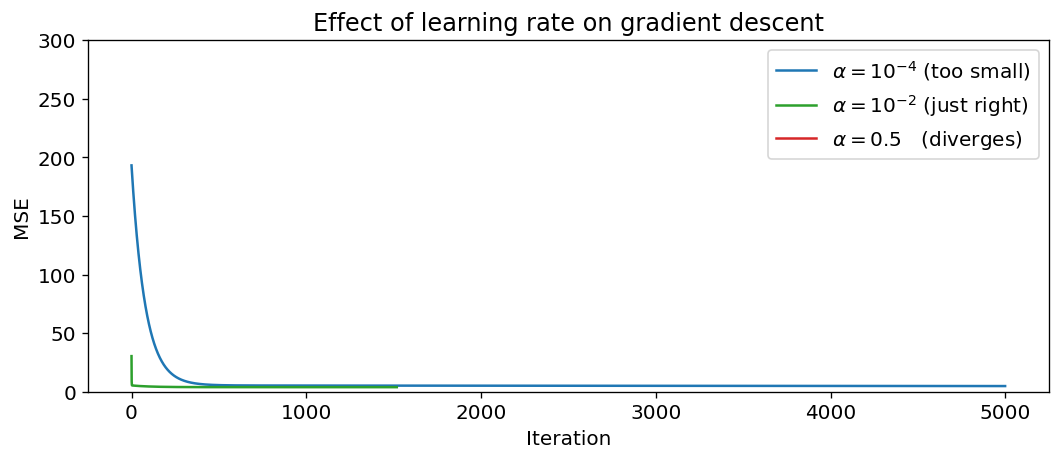

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

configs = [
    (1e-4, 5000, 'C0', r'$\alpha=10^{-4}$ (too small)'),
    (1e-2, 5000, 'C2', r'$\alpha=10^{-2}$ (just right)'),
    (5e-1, 100,  'C3', r'$\alpha=0.5$   (diverges)'),
]

for lr, n_iters, color, label in configs:
    m = LinearRegressionGD(lr=lr, n_iters=n_iters)
    try:
        m.fit(X, y)
        hist = m.history_
    except Exception:
        hist = [float('nan')]
    hist = [min(h, 1e6) for h in hist]  # cap for display
    ax.plot(hist, color=color, lw=1.5, label=label)

ax.set_xlabel('Iteration'); ax.set_ylabel('MSE')
ax.set_title('Effect of learning rate on gradient descent'); ax.legend()
ax.set_ylim(0, 300)
plt.tight_layout(); plt.show()

---
# Part 5 — Comparison & Validation

## 5.1 Head-to-head

In [8]:
from sklearn.linear_model import LinearRegression as SkLearnLR

# sklearn fits on raw features (handles intercept internally)
sk = SkLearnLR().fit(x_raw.reshape(-1, 1), y)

print(f"{'Method':<25} {'beta0 (intercept)':>20} {'beta1 (slope)':>15} {'MSE':>10}")
print('-' * 72)
print(f"{'True process':<25} {TRUE_BETA0:>20.4f} {TRUE_BETA1:>15.4f} {'—':>10}")
print(f"{'Normal Equation':<25} {b0_ne:>20.4f} {b1_ne:>15.4f} {model_normal.mse(X,y):>10.4f}")
print(f"{'Gradient Descent':<25} {b0_gd:>20.4f} {b1_gd:>15.4f} {model_gd.mse(X,y):>10.4f}")
print(f"{'scikit-learn':<25} {sk.intercept_:>20.4f} {sk.coef_[0]:>15.4f} {'—':>10}")

Method                       beta0 (intercept)   beta1 (slope)        MSE
------------------------------------------------------------------------
True process                            3.0000          2.0000          —
Normal Equation                         2.8974          2.0153     3.8355
Gradient Descent                        2.8953          2.0157     3.8355
scikit-learn                            2.8974          2.0153          —


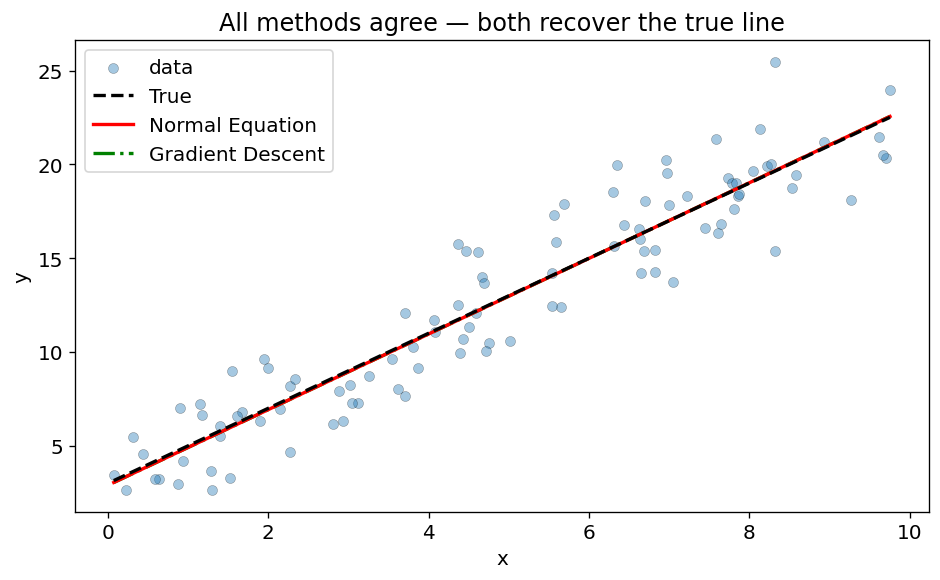

AssertionError: 
Not equal to tolerance rtol=1e-07, atol=0.001

Mismatched elements: 1 / 2 (50%)
Mismatch at index:
 [0]: 2.8973994531005816 (ACTUAL), 2.895286359481429 (DESIRED)
Max absolute difference among violations: 0.00211309
Max relative difference among violations: 0.00072984
 ACTUAL: array([2.897399, 2.015326])
 DESIRED: array([2.895286, 2.015659])

In [9]:
# --- Final overlay plot ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x_raw, y, alpha=0.4, edgecolors='k', linewidths=0.3, label='data', zorder=1)

# True line
ax.plot(x_line, TRUE_BETA0 + TRUE_BETA1 * x_line,
        'k--', lw=2, label='True', zorder=5)

# Normal equation
ax.plot(x_line, model_normal.predict(X_line),
        'r-', lw=2, label='Normal Equation', zorder=4)

# Gradient descent
ax.plot(x_line, model_gd.predict(X_line),
        'g-.', lw=2, label='Gradient Descent', zorder=3)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('All methods agree — both recover the true line')
ax.legend()
plt.tight_layout(); plt.show()

# Numerical check: both methods should match to many decimal places
np.testing.assert_allclose(model_normal.beta_, model_gd.beta_, atol=1e-3)
print("Assertion passed: Normal Equation ≈ Gradient Descent  ✓")

---
# Part 6 — Multivariate Extension

Both implementations already handle multiple features — nothing changes in the code.  
Let's quickly verify on a 3-feature dataset.

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \epsilon
= 1 + 2x_1 - 3x_2 + 0.5x_3 + \epsilon
$$

In [10]:
rng2 = np.random.default_rng(7)
n2   = 200
p2   = 3

X_raw_mv  = rng2.uniform(-2, 2, size=(n2, p2))
true_beta = np.array([1.0, 2.0, -3.0, 0.5])     # [beta0, beta1, beta2, beta3]
noise_mv  = rng2.normal(0, 0.5, size=n2)
y_mv      = true_beta[0] + X_raw_mv @ true_beta[1:] + noise_mv

# Design matrix
X_mv = np.column_stack([np.ones(n2), X_raw_mv])  # (200, 4)

# Fit
mn = LinearRegressionNormal().fit(X_mv, y_mv)
mg = LinearRegressionGD(lr=0.05, n_iters=3000).fit(X_mv, y_mv)

print(f"{'Coeff':<8} {'True':>10} {'Normal Eq':>12} {'Grad Desc':>12}")
print('-' * 44)
labels = ['beta0', 'beta1', 'beta2', 'beta3']
for i, (lbl, tb) in enumerate(zip(labels, true_beta)):
    print(f"{lbl:<8} {tb:>10.3f} {mn.beta_[i]:>12.4f} {mg.beta_[i]:>12.4f}")

np.testing.assert_allclose(mn.beta_, mg.beta_, atol=1e-2)
print("\nMultivariate assertion passed  ✓")

  Converged at iteration 98
Coeff          True    Normal Eq    Grad Desc
--------------------------------------------
beta0         1.000       1.0002       1.0000
beta1         2.000       1.9700       1.9699
beta2        -3.000      -2.9696      -2.9695
beta3         0.500       0.5261       0.5261

Multivariate assertion passed  ✓


---
# Summary

## What we built

| | Normal Equation | Gradient Descent |
|--|--|--|
| **Approach** | Analytical | Iterative |
| **Formula** | $\boldsymbol{\beta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ | $\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} - \alpha \dfrac{2}{n}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\beta}-\mathbf{y})$ |
| **Complexity** | $O(np^2 + p^3)$ | $O(np)$ per step |
| **Scales to large $p$?** | No | Yes |
| **Hyperparameters** | None | Learning rate, iterations |
| **Requires tuning?** | No | Yes |

## Key formulas to remember

$$
\underbrace{\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2}_{\text{loss}}
\qquad
\underbrace{\nabla \mathcal{L} = \frac{2}{n}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\beta}-\mathbf{y})}_{\text{gradient}}
\qquad
\underbrace{\boldsymbol{\beta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}_{\text{normal equation}}
$$

---

## What's next?

| Notebook | Topic |
|----------|-------|
| `02_Ridge_Lasso_Regularisation.ipynb` | $L_2$ and $L_1$ penalties — taming overfitting |
| `03_Logistic_Regression.ipynb` | Binary classification with sigmoid + cross-entropy |
| `04_Decision_Trees.ipynb` | Entropy, information gain, CART splitting |
| `05_Neural_Networks.ipynb` | Backpropagation from scratch |

---
*DS100 · Built from first principles · NumPy only*